In [1]:
import pandas as pd
import gseapy as gp
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
ROOT = Path("/home/hanwenying")
DATADIR = ROOT / "rothman-data/transcriptlength"

In [3]:
kegg_symbols = gp.get_library(name='KEGG_2026', organism='Human')

In [4]:
rnk_t10 = pd.read_csv(DATADIR / "tstats_10.tsv", sep='\t')
rnk_res = pd.read_csv(DATADIR / "forgsea.tsv", sep='\t')
res_symbols = pd.read_csv(DATADIR / "forgsea-symbols.tsv", sep='\t')
t10_symbols = pd.read_csv(DATADIR / "t10-symbols.tsv", sep='\t')

In [6]:
# bm = gp.Biomart()

# queries ={'ensembl_gene_id': list(rnk_t10['GENE']) } 
# results = bm.query(dataset='hsapiens_gene_ensembl',
#                    attributes=['ensembl_gene_id', 'external_gene_name'],
#                    filters=queries)
# results.columns = ['GENE', 'GENE_SYMBOL']

In [5]:
res = rnk_res.merge(res_symbols, on='GENE')
res = res.dropna()

In [6]:
rest = rnk_t10.merge(t10_symbols, on='GENE')
rest = rest.dropna()

In [7]:
nthreads = 20

In [8]:
rnk_res = res.drop(columns=['GENE','TSTATISTIC', 'LOGLENGTH'])

In [10]:
rnk_t10 = rest.drop(columns=['GENE', 'PVALUE'])

In [11]:
rnk_res = rnk_res.set_index('SYMBOL')
rnk_t10 = rnk_t10.set_index('SYMBOL')

In [12]:
pr_res = gp.prerank(rnk=rnk_res,
				gene_sets='KEGG_2026',
				threads=nthreads,
				min_size=5,
				max_size=10000,
				permutation_num=5000,
				outdir=None,
				seed=24,
				verbose=True)

pr_t10 = gp.prerank(rnk=rnk_t10,
				gene_sets='KEGG_2026',
				threads=nthreads,
				min_size=5,
				max_size=10000,
				permutation_num=5000,
				outdir=None,
				seed=24,
				verbose=True)

2026-03-23 12:23:54,766 [INFO] Parsing data files for GSEA.............................
2026-03-23 12:23:54,783 [INFO] Enrichr library gene sets already downloaded in: /home/hanwenying/.cache/gseapy, use local file


2026-03-23 12:23:54,805 [INFO] 0007 gene_sets have been filtered out when max_size=10000 and min_size=5
2026-03-23 12:23:54,806 [INFO] 0345 gene_sets used for further statistical testing.....
2026-03-23 12:23:54,806 [INFO] Start to run GSEA...Might take a while..................
2026-03-23 12:24:05,826 [INFO] Congratulations. GSEApy runs successfully................

2026-03-23 12:24:05,837 [INFO] Parsing data files for GSEA.............................
2026-03-23 12:24:05,852 [INFO] Enrichr library gene sets already downloaded in: /home/hanwenying/.cache/gseapy, use local file
2026-03-23 12:24:05,872 [INFO] 0007 gene_sets have been filtered out when max_size=10000 and min_size=5
2026-03-23 12:24:05,873 [INFO] 0345 gene_sets used for further statistical testing.....
2026-03-23 12:24:05,873 [INFO] Start to run GSEA...Might take a while..................
2026-03-23 12:24:16,057 [INFO] Congratulations. GSEApy runs successfully................



In [13]:
pr_res.res2d.to_csv(DATADIR / "pr_res.tsv", sep='\t', index=False)
pr_t10.res2d.to_csv(DATADIR / "pr_t10.tsv", sep='\t', index=False)

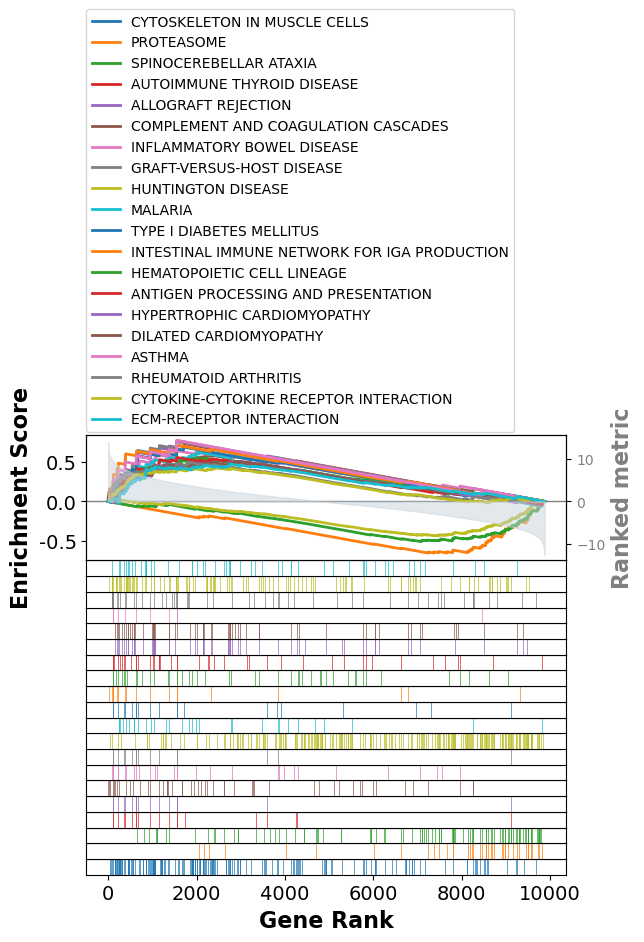

In [14]:
terms = pr_res.res2d.Term
axs = pr_res.plot(terms=terms[0:20],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

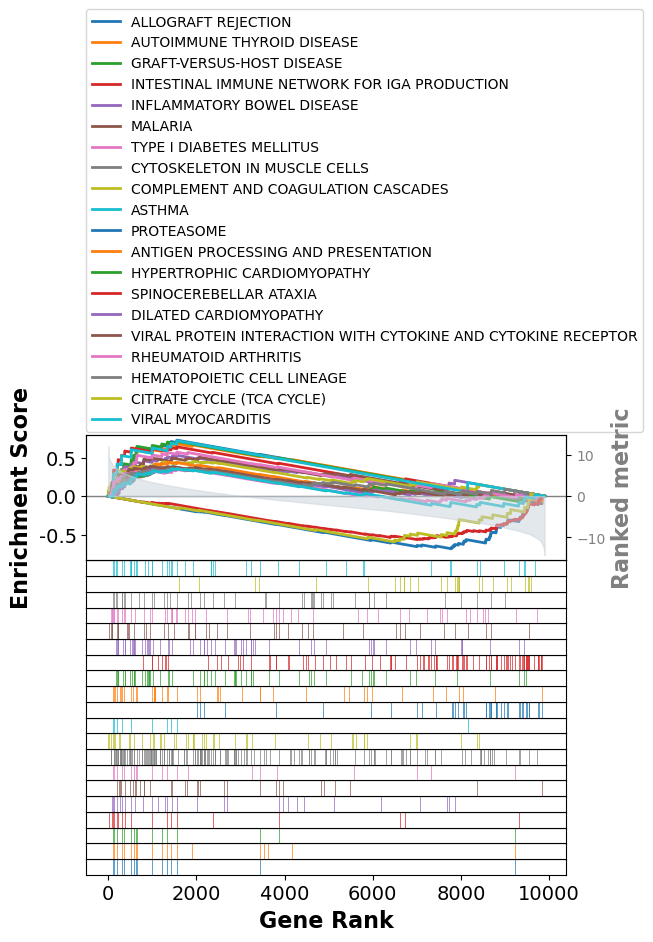

In [15]:
terms = pr_t10.res2d.Term
axs = pr_t10.plot(terms=terms[0:20],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )

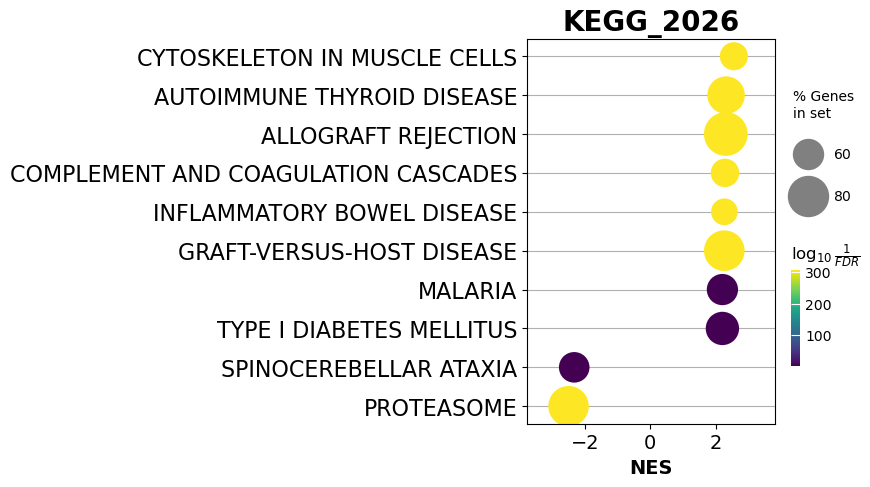

In [16]:
ax = gp.dotplot(pr_res.res2d,
             column="FDR q-val",
             title='KEGG_2026',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,5), cutoff=0.25, show_ring=False)

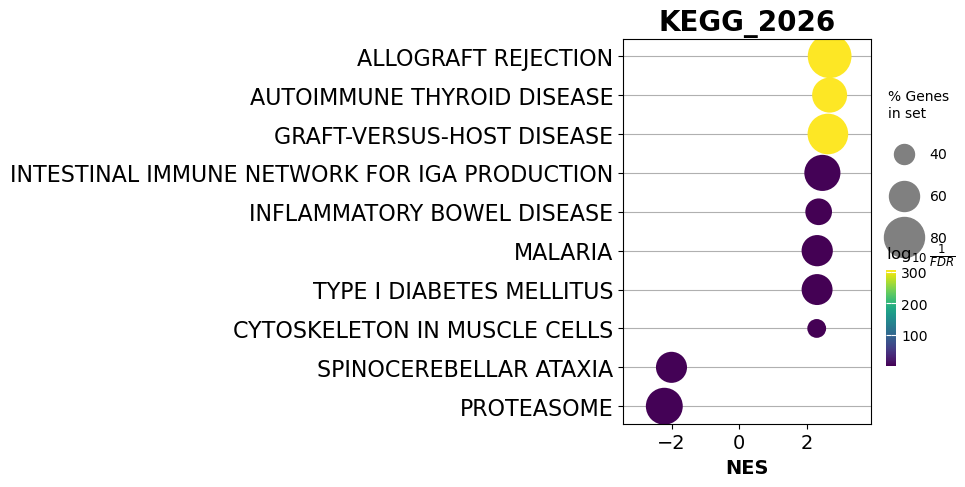

In [17]:
ax = gp.dotplot(pr_t10.res2d,
             column="FDR q-val",
             title='KEGG_2026',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,5), cutoff=0.25, show_ring=False)